# 09 — LangChain and LangGraph Primer: State, Memory, Checkpoints, and Human Review

> **DOMAIN-NEUTRAL PRIMER:** This notebook teaches reusable LangChain and LangGraph concepts independently of any business domain.

It answers four questions:

1. What information is moving through the workflow **right now**?
2. How can one conversation safely pause and resume?
3. What selected information should remain available in a different conversation?
4. How can a human approve, edit, or reject a proposed action before it executes?

The default `model_free` path uses real LangGraph graphs, checkpointers, stores, and interrupts without calling any language model. Optional sections reuse the same boundaries with Ollama Gemma 4 or OpenAI.

## The core mental model

![State, checkpoints, and long-term memory](../docs/images/state-memory-primer-mental-model.png)

| Concept | Plain-language meaning | Typical identity | Lifetime |
|---|---|---|---|
| **State** | The working values flowing through graph nodes | One graph invocation | During execution unless checkpointed |
| **Checkpoint** | A saved snapshot of graph state | `thread_id` | Across calls to the same thread |
| **Long-term store** | Selected JSON documents intentionally shared beyond one thread | `namespace + key` | Until updated or deleted |
| **Human review** | A safe pause before a sensitive action | The paused thread/checkpoint | Until a reviewer resumes it |

Two important boundaries:

- A checkpointer is not automatically a cross-thread user profile.
- A long-term store should not contain every intermediate graph value.

## Three execution modes

![One architecture, three execution modes](../docs/images/state-memory-primer-execution-modes.png)

| Mode | Model | Credentials/service | What runs |
|---|---|---|---|
| `model_free` | None | None | Every deterministic state, checkpoint, store, and HITL example |
| `ollama_gemma4` | `gemma4:e4b` | Local Ollama service and downloaded model | The model-free foundation plus a `create_agent()` memory/HITL example |
| `openai` | `gpt-5-mini` | `OPENAI_API_KEY` | The same `create_agent()` memory/HITL example using OpenAI |

The model changes. The state, checkpoint, store, identity, and approval boundaries do not.

Select a mode before starting Jupyter:

```bash
STATE_MEMORY_PRIMER_MODE=model_free uv run jupyter lab notebooks/09_langchain_langgraph_state_memory_primer.ipynb
STATE_MEMORY_PRIMER_MODE=ollama_gemma4 uv run jupyter lab notebooks/09_langchain_langgraph_state_memory_primer.ipynb
STATE_MEMORY_PRIMER_MODE=openai uv run jupyter lab notebooks/09_langchain_langgraph_state_memory_primer.ipynb
```

In [1]:
import json
import operator
import os
from dataclasses import dataclass
from importlib.metadata import version
from typing import Annotated, Literal
from uuid import uuid4

from dotenv import load_dotenv
from IPython.display import HTML, Image, display
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langchain.messages import AIMessage, HumanMessage, ToolMessage
from langchain.tools import ToolRuntime, tool
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.runtime import Runtime
from langgraph.store.memory import InMemoryStore
from langgraph.types import Command, interrupt
from typing_extensions import TypedDict

if os.getenv("STATE_MEMORY_PRIMER_LOAD_DOTENV", "1") == "1":
    load_dotenv()

MODE = os.getenv("STATE_MEMORY_PRIMER_MODE", "model_free").strip().lower()
VALID_MODES = {"model_free", "ollama_gemma4", "openai"}
if MODE not in VALID_MODES:
    raise ValueError(f"STATE_MEMORY_PRIMER_MODE must be one of {sorted(VALID_MODES)}")

AUTO_REVIEW = os.getenv("STATE_MEMORY_PRIMER_AUTO_REVIEW", "0") == "1"

print(
    f"mode={MODE} langchain={version('langchain')} langgraph={version('langgraph')} "
    f"openai_key_configured={bool(os.getenv('OPENAI_API_KEY'))}"
)

mode=model_free langchain=1.3.16 langgraph=1.2.11 openai_key_configured=True


In [2]:
def card(title: str, body: str, color: str = "#4338ca") -> None:
    display(
        HTML(
            f"""
            <div style="border:1px solid #dbeafe;border-left:6px solid {color};
                        border-radius:12px;padding:14px 18px;margin:10px 0;
                        background:#fff;font-family:system-ui;">
              <div style="font-weight:750;font-size:17px;color:#111827">{title}</div>
              <div style="margin-top:6px;color:#374151;line-height:1.5">{body}</div>
            </div>
            """
        )
    )


def table(rows: list[tuple[str, str]]) -> None:
    body = "".join(
        f"<tr><td style='font-weight:700;padding:7px 12px'>{left}</td>"
        f"<td style='padding:7px 12px'>{right}</td></tr>"
        for left, right in rows
    )
    display(
        HTML(
            "<table style='border-collapse:collapse;width:100%;font-family:system-ui'>"
            f"{body}</table>"
        )
    )


def display_graph(
    compiled_graph,
    *,
    xray: bool | int = False,
    output_file_path=None,
):
    """Render and display a compiled LangGraph as a Mermaid PNG."""
    render_options = {}
    if output_file_path is not None:
        render_options["output_file_path"] = str(output_file_path)

    png = compiled_graph.get_graph(xray=xray).draw_mermaid_png(**render_options)
    image = Image(data=png)
    display(image)
    return image


def render_messages(messages) -> None:
    """Render the complete agent message/tool trace without exposing hidden reasoning."""
    for index, message in enumerate(messages, start=1):
        if isinstance(message, HumanMessage):
            card(f"{index}. Human", str(message.content), "#2563eb")
        elif isinstance(message, ToolMessage):
            card(
                f"{index}. Tool observation · {message.name or 'tool'}",
                f"<pre style='white-space:pre-wrap'>{message.content}</pre>",
                "#059669",
            )
        elif isinstance(message, AIMessage):
            calls = getattr(message, "tool_calls", []) or []
            if calls:
                formatted = "".join(
                    "<div><b>Tool:</b> "
                    + str(call.get("name"))
                    + "<br><b>Arguments:</b> <code>"
                    + json.dumps(call.get("args", {}), sort_keys=True)
                    + "</code></div>"
                    for call in calls
                )
                card(f"{index}. Model requested tool call", formatted, "#7c3aed")
            if message.content:
                card(f"{index}. Model response", str(message.content), "#7c3aed")

## Part 1 — State: values that move through graph nodes

State is a typed shared data structure. Each node receives the current state and returns an update. A **reducer** controls how an update combines with the existing value.

Here, `numbers` and `events` use `operator.add`, so later node updates append rather than replace. `total` uses normal replacement.

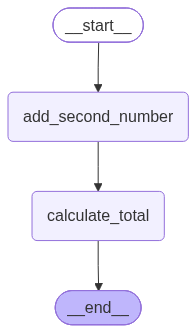

Final numbers,"[2, 5]"
Events,received 2 → added 5 → calculated total
Total,7


STATE_TOTAL 7


In [3]:
class CalculationState(TypedDict):
    numbers: Annotated[list[int], operator.add]
    events: Annotated[list[str], operator.add]
    total: int


def add_second_number(_state: CalculationState) -> dict:
    return {"numbers": [5], "events": ["added 5"]}


def calculate_total(state: CalculationState) -> dict:
    return {
        "total": sum(state["numbers"]),
        "events": ["calculated total"],
    }


calculation_builder = StateGraph(CalculationState)
calculation_builder.add_node("add_second_number", add_second_number)
calculation_builder.add_node("calculate_total", calculate_total)
calculation_builder.add_edge(START, "add_second_number")
calculation_builder.add_edge("add_second_number", "calculate_total")
calculation_builder.add_edge("calculate_total", END)
calculation_graph = calculation_builder.compile()
display_graph(calculation_graph)

calculation = calculation_graph.invoke(
    {"numbers": [2], "events": ["received 2"], "total": 0}
)
table(
    [
        ("Final numbers", str(calculation["numbers"])),
        ("Events", " → ".join(calculation["events"])),
        ("Total", str(calculation["total"])),
    ]
)
print(f"STATE_TOTAL {calculation['total']}")

### Message state is ordinary graph state with a useful reducer

LangChain messages are normally held under a `messages` key. `add_messages` appends new messages and replaces a message when the same message ID is updated. The model-free node below gives a deterministic response so the checkpoint behavior is easy to inspect.

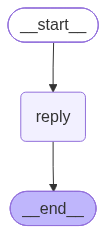

staate : {'messages': [HumanMessage(content='First message', additional_kwargs={}, response_metadata={}, id='4a645a95-c55f-496a-bf94-108f9753c4ab')], 'turn_count': 0}
staate : {'messages': [HumanMessage(content='First message', additional_kwargs={}, response_metadata={}, id='4a645a95-c55f-496a-bf94-108f9753c4ab'), AIMessage(content='Acknowledged: First message', additional_kwargs={}, response_metadata={}, id='c4bef4ff-fda0-4c47-8d54-237fc79e965c', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Second message', additional_kwargs={}, response_metadata={}, id='cffcbd06-2764-4582-b814-480f42e464a1')], 'turn_count': 1}
staate : {'messages': [HumanMessage(content='Independent message', additional_kwargs={}, response_metadata={}, id='abe1bc36-df7e-4c96-b772-9e76912bbff9')], 'turn_count': 0}
SAME_THREAD_TURNS 2
DIFFERENT_THREAD_ISOLATED True


In [4]:
class ConversationState(TypedDict):
    messages: Annotated[list, add_messages]
    turn_count: int


def deterministic_reply(state: ConversationState) -> dict:
    print(f"staate : {state}")
    latest = next(
        message for message in reversed(state["messages"]) if isinstance(message, HumanMessage)
    )
    return {
        "messages": [AIMessage(content=f"Acknowledged: {latest.content}")],
        "turn_count": state.get("turn_count", 0) + 1,
    }


conversation_checkpointer = InMemorySaver()
conversation_builder = StateGraph(ConversationState)
conversation_builder.add_node("reply", deterministic_reply)
conversation_builder.add_edge(START, "reply")
conversation_builder.add_edge("reply", END)
conversation_graph = conversation_builder.compile(checkpointer=conversation_checkpointer)
# conversation_graph = conversation_builder.compile()

display_graph(conversation_graph)

thread_a = {"configurable": {"thread_id": "primer-thread-a"}}
thread_b = {"configurable": {"thread_id": "primer-thread-b"}}

conversation_graph.invoke(
    {"messages": [HumanMessage(content="First message")], "turn_count": 0},
    config=thread_a,
)
thread_a_result = conversation_graph.invoke(
    {"messages": [HumanMessage(content="Second message")]},
    config=thread_a,
)
thread_b_result = conversation_graph.invoke(
    {"messages": [HumanMessage(content="Independent message")], "turn_count": 0},
    config=thread_b,
)

different_thread_isolated = (
    thread_a_result["turn_count"] == 2 and thread_b_result["turn_count"] == 1
)
print(f"SAME_THREAD_TURNS {thread_a_result['turn_count']}")
print(f"DIFFERENT_THREAD_ISOLATED {different_thread_isolated}")

## Part 2 — Checkpoints: saved state for one thread

![Thread memory and cross-thread memory](../docs/images/state-memory-primer-thread-boundaries.png)

Compiling with a checkpointer makes LangGraph save snapshots after graph steps. Reusing the same `thread_id` loads and extends that thread. A different `thread_id` starts separate state.

Checkpoints enable:

- multi-turn thread memory;
- pause and resume;
- checkpoint history and debugging;
- time travel and alternative execution branches;
- recovery from a previously completed step.

`InMemorySaver` is for learning and tests. Production processes normally use a database-backed saver such as PostgreSQL.

In [5]:
history = list(conversation_graph.get_state_history(thread_a))
print(f"history : {history} ")
latest_snapshot = conversation_graph.get_state(thread_a)
checkpoint_history_available = len(history) >= 2

table(
    [
        ("Thread", thread_a["configurable"]["thread_id"]),
        ("Saved snapshots", str(len(history))),
        ("Latest turn count", str(latest_snapshot.values["turn_count"])),
        ("Next nodes", str(latest_snapshot.next)),
    ]
)
print(f"CHECKPOINT_HISTORY_AVAILABLE {checkpoint_history_available}")

history : [StateSnapshot(values={'messages': [HumanMessage(content='First message', additional_kwargs={}, response_metadata={}, id='4a645a95-c55f-496a-bf94-108f9753c4ab'), AIMessage(content='Acknowledged: First message', additional_kwargs={}, response_metadata={}, id='c4bef4ff-fda0-4c47-8d54-237fc79e965c', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Second message', additional_kwargs={}, response_metadata={}, id='cffcbd06-2764-4582-b814-480f42e464a1'), AIMessage(content='Acknowledged: Second message', additional_kwargs={}, response_metadata={}, id='645343fb-60a3-4e6f-90b7-29f54e35afae', tool_calls=[], invalid_tool_calls=[])], 'turn_count': 2}, next=(), config={'configurable': {'thread_id': 'primer-thread-a', 'checkpoint_ns': '', 'checkpoint_id': '1f1a2b9d-791c-62f2-8004-45d2cd1a7fc3'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-08-28T08:24:09.449943+00:00', parent_config={'configurable': {'thread_id': 'primer-thread-a', 'checkpoint_ns': ''

Thread,primer-thread-a
Saved snapshots,6
Latest turn count,2
Next nodes,()


CHECKPOINT_HISTORY_AVAILABLE True


## Part 3 — Long-term memory: selected information across threads

A LangGraph **Store** holds JSON documents under a namespace and key. The application—not the checkpointer—decides what belongs there.

For this example:

- namespace: `("user-a", "preferences")`
- key: `"response_style"`
- value: `{"value": "concise"}`

Using the same namespace/key again updates the logical preference rather than adding a duplicate.

In [6]:
long_term_store = InMemoryStore()
user_a_namespace = ("user-a", "preferences")
user_b_namespace = ("user-b", "preferences")

long_term_store.put(
    user_a_namespace,
    "response_style",
    {"value": "concise", "source": "explicit setting"},
)
first_preference = long_term_store.get(user_a_namespace, "response_style")
cross_thread_memory = first_preference.value["value"]

long_term_store.put(
    user_a_namespace,
    "response_style",
    {"value": "detailed", "source": "explicit update"},
)
updated_preference = long_term_store.get(user_a_namespace, "response_style")
user_a_items = long_term_store.search(user_a_namespace)
user_b_items = long_term_store.search(user_b_namespace)

assert len(user_a_items) == 1
assert user_b_items == []

table(
    [
        ("Initial cross-thread value", cross_thread_memory),
        ("Updated value", updated_preference.value["value"]),
        ("Items at the same business key", str(len(user_a_items))),
        ("User B sees User A memory", str(bool(user_b_items))),
    ]
)
print(f"CROSS_THREAD_MEMORY {cross_thread_memory}")
print(f"UPDATED_MEMORY {updated_preference.value['value']}")

Initial cross-thread value,concise
Updated value,detailed
Items at the same business key,1
User B sees User A memory,False


CROSS_THREAD_MEMORY concise
UPDATED_MEMORY detailed


### Reading the store from inside a graph node

Identity belongs in trusted runtime context, not in model-generated arguments. The node below reads the store using `runtime.context.user_id`.

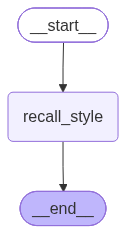

In [7]:
@dataclass(frozen=True)
class UserContext:
    user_id: str


class RecallState(TypedDict):
    recalled_style: str


def recall_style(_state: RecallState, runtime: Runtime[UserContext]) -> dict:
    item = runtime.store.get(
        (runtime.context.user_id, "preferences"),
        "response_style",
    )
    return {"recalled_style": item.value["value"] if item else "not set"}


recall_builder = StateGraph(RecallState, context_schema=UserContext)
recall_builder.add_node("recall_style", recall_style)
recall_builder.add_edge(START, "recall_style")
recall_builder.add_edge("recall_style", END)
recall_graph = recall_builder.compile(store=long_term_store)

display_graph(recall_graph)

recalled = recall_graph.invoke(
    {"recalled_style": ""},
    context=UserContext(user_id="user-a"),
)
card("Graph node recalled long-term memory", recalled["recalled_style"], "#0f766e")

## Part 4 — Human-in-the-loop: pause before a side effect

![Human review lifecycle](../docs/images/state-memory-primer-hitl-lifecycle.png)

The graph below proposes a simulated notification, then calls `interrupt()`. LangGraph saves the thread state and returns control to the caller. The caller resumes with `Command(resume=...)` using the **same** `thread_id`.

The review decision is JSON-serializable:

- `{"decision": "approve"}` executes the original draft;
- `{"decision": "edit", "draft": "..."}` executes the edited draft;
- `{"decision": "reject", "feedback": "..."}` performs no side effect.

The simulated side effect occurs in a later node—never before the interrupt.

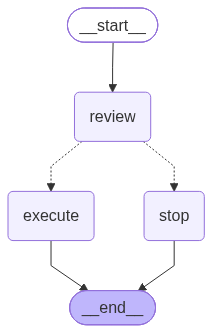

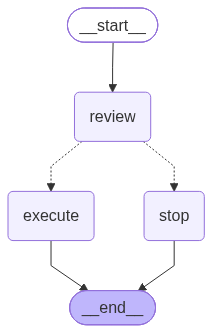

In [8]:
class ApprovalState(TypedDict):
    draft: str
    decision: str
    feedback: str
    published: Annotated[list[str], operator.add]


published_actions: list[str] = []


def review_action(state: ApprovalState) -> dict:
    response = interrupt(
        {
            "action": "publish_notification",
            "draft": state["draft"],
            "allowed_decisions": ["approve", "edit", "reject"],
        }
    )
    decision = response["decision"]
    if decision == "edit":
        return {"decision": "edit", "draft": response["draft"], "feedback": ""}
    if decision == "reject":
        return {
            "decision": "reject",
            "feedback": response.get("feedback", "Rejected by reviewer"),
        }
    if decision == "approve":
        return {"decision": "approve", "feedback": ""}
    raise ValueError(f"unsupported review decision: {decision}")


def after_review(state: ApprovalState) -> Literal["execute", "stop"]:
    return "execute" if state["decision"] in {"approve", "edit"} else "stop"


def execute_action(state: ApprovalState) -> dict:
    published_actions.append(state["draft"])
    return {"published": [state["draft"]]}


def stop_action(_state: ApprovalState) -> dict:
    return {"published": []}


approval_checkpointer = InMemorySaver()
approval_builder = StateGraph(ApprovalState)
approval_builder.add_node("review", review_action)
approval_builder.add_node("execute", execute_action)
approval_builder.add_node("stop", stop_action)
approval_builder.add_edge(START, "review")
approval_builder.add_conditional_edges(
    "review",
    after_review,
    {"execute": "execute", "stop": "stop"},
)
approval_builder.add_edge("execute", END)
approval_builder.add_edge("stop", END)

approval_graph = approval_builder.compile(checkpointer=approval_checkpointer)

display_graph(approval_graph)

In [9]:
def start_review(thread_id: str, draft: str):
    config = {"configurable": {"thread_id": thread_id}}
    pending = approval_graph.invoke(
        {"draft": draft, "decision": "pending", "feedback": "", "published": []},
        config=config,
    )
    return config, pending


approve_config, approve_pending = start_review(
    "approval-thread-approve",
    "Your weekly summary is ready.",
)
hitl_paused = "__interrupt__" in approve_pending and published_actions == []
paused_snapshot = approval_graph.get_state(approve_config)

card(
    "Execution paused",
    "The checkpoint contains the draft, and no notification has been published.",
    "#7c3aed",
)
table(
    [
        ("Draft in saved state", paused_snapshot.values["draft"]),
        ("Next node", str(paused_snapshot.next)),
        ("Published actions", str(published_actions)),
    ]
)
print(f"HITL_PAUSED {hitl_paused}")

Draft in saved state,Your weekly summary is ready.
Next node,"('review',)"
Published actions,[]


HITL_PAUSED True


In [10]:
approved_result = approval_graph.invoke(
    Command(resume={"decision": "approve"}),
    config=approve_config,
)
hitl_approved = approved_result["published"] == ["Your weekly summary is ready."]
print(f"HITL_APPROVED {hitl_approved}")

HITL_APPROVED True


In [11]:
edit_config, edit_pending = start_review(
    "approval-thread-edit",
    "Original notification.",
)
assert "__interrupt__" in edit_pending
edited_result = approval_graph.invoke(
    Command(
        resume={
            "decision": "edit",
            "draft": "Edited notification approved by the reviewer.",
        }
    ),
    config=edit_config,
)
hitl_edited = edited_result["published"] == [
    "Edited notification approved by the reviewer."
]
print(f"HITL_EDITED {hitl_edited}")

HITL_EDITED True


In [12]:
published_before_reject = list(published_actions)
reject_config, reject_pending = start_review(
    "approval-thread-reject",
    "This notification should not be sent.",
)
assert "__interrupt__" in reject_pending
rejected_result = approval_graph.invoke(
    Command(resume={"decision": "reject", "feedback": "Needs revision"}),
    config=reject_config,
)
hitl_rejected = (
    rejected_result["published"] == []
    and published_actions == published_before_reject
    and rejected_result["feedback"] == "Needs revision"
)
print(f"HITL_REJECTED {hitl_rejected}")

HITL_REJECTED True


### Rules that keep interrupts safe

1. Use a checkpointer and stable `thread_id`.
2. Pass only JSON-serializable interrupt and resume values.
3. Do not wrap `interrupt()` in a broad `try/except`.
4. A node restarts from its beginning when resumed. Work before the interrupt must therefore be idempotent.
5. Put external side effects after review, or make them independently idempotent.
6. Human approval does not replace authorization. Trusted server identity and permission checks still apply.
7. Use a durable checkpointer in production; an in-memory pause disappears when the process exits.

## Part 5 — The same boundaries inside a LangChain agent

LangChain's `create_agent()` runs on LangGraph. The agent receives:

- an `InMemorySaver` for thread state;
- an `InMemoryStore` for cross-thread memory;
- real `@tool` functions that access trusted runtime context;
- `HumanInTheLoopMiddleware` that pauses write-like tools.

The model may propose a tool call, but the middleware interrupts **before** the tool executes.

In [13]:
@tool
def read_preference(key: str, runtime: ToolRuntime[UserContext]) -> str:
    """Read one preference for the authenticated user."""
    item = runtime.store.get(
        (runtime.context.user_id, "preferences"),
        key,
    )
    return json.dumps(item.value if item else {"value": "not set"})


@tool
def save_preference(key: str, value: str, runtime: ToolRuntime[UserContext]) -> str:
    """Save or replace one preference after human approval."""
    runtime.store.put(
        (runtime.context.user_id, "preferences"),
        key,
        {"value": value, "source": "approved agent tool"},
    )
    return json.dumps({"saved": True, "key": key, "value": value})


@tool
def publish_notification(message: str, runtime: ToolRuntime[UserContext]) -> str:
    """Publish a simulated notification after human approval."""
    key = f"notification-{uuid4().hex[:8]}"
    runtime.store.put(
        (runtime.context.user_id, "notifications"),
        key,
        {"message": message, "status": "published"},
    )
    return json.dumps({"published": True, "message": message})


AGENT_TOOLS = [read_preference, save_preference, publish_notification]
table([(tool.name, tool.description) for tool in AGENT_TOOLS])

read_preference,Read one preference for the authenticated user.
save_preference,Save or replace one preference after human approval.
publish_notification,Publish a simulated notification after human approval.


In [14]:
def build_chat_model(mode: str):
    if mode == "ollama_gemma4":
        return ChatOllama(
            model="gemma4:e4b",
            temperature=0,
            validate_model_on_init=True,
        )
    if mode == "openai":
        return ChatOpenAI(
            model="gpt-5-mini",
            reasoning_effort="low",
            timeout=30,
            max_retries=0,
        )
    raise ValueError("A chat model is available only in ollama_gemma4 or openai mode")

In [15]:
def build_memory_agent(mode: str):
    agent_checkpointer = InMemorySaver()
    agent_store = InMemoryStore()
    agent = create_agent(
        model=build_chat_model(mode),
        tools=AGENT_TOOLS,
        system_prompt=(
            "You are a memory teaching assistant. Follow the user's requested tool action "
            "exactly once. Use tools for reading or writing memory. Never claim a write "
            "succeeded until its tool observation confirms it."
        ),
        middleware=[
            HumanInTheLoopMiddleware(
                interrupt_on={
                    "read_preference": False,
                    "save_preference": {
                        "allowed_decisions": ["approve", "edit", "reject"]
                    },
                    "publish_notification": {
                        "allowed_decisions": ["approve", "edit", "reject"]
                    },
                },
                description_prefix="Review this memory-changing action",
            )
        ],
        context_schema=UserContext,
        checkpointer=agent_checkpointer,
        store=agent_store,
    )
    return agent, agent_checkpointer, agent_store

### Optional live agent run

This cell is skipped in `model_free` mode. In a provider mode it asks the model to call `save_preference`, prints the complete returned message/tool trace, and displays the interrupt payload. Set `STATE_MEMORY_PRIMER_AUTO_REVIEW=1` only when you want the disposable notebook run to approve and resume automatically.

No hidden chain-of-thought is displayed. The trace contains public model messages, tool names, arguments, observations, interrupts, and the final response.

In [16]:
live_agent_result = None
live_agent_final = None

if MODE == "model_free":
    print("LIVE_AGENT skipped mode=model_free")
else:
    if MODE == "openai" and not os.getenv("OPENAI_API_KEY"):
        raise RuntimeError("OPENAI_API_KEY is required for openai mode")

    live_agent, live_agent_checkpointer, live_agent_store = build_memory_agent(MODE)
    live_config = {"configurable": {"thread_id": f"live-primer-{MODE}"}}
    live_context = UserContext(user_id=f"primer-{MODE}-user")
    live_agent_result = live_agent.invoke(
        {
            "messages": [
                HumanMessage(
                    content=(
                        "Call save_preference exactly once with key response_style "
                        "and value concise. Do not call another tool."
                    )
                )
            ]
        },
        config=live_config,
        context=live_context,
    )
    render_messages(live_agent_result["messages"])
    live_interrupts = live_agent_result.get("__interrupt__", [])
    card(
        "Agent paused for human review",
        f"<pre style='white-space:pre-wrap'>{live_interrupts}</pre>",
        "#7c3aed",
    )
    print(f"LIVE_AGENT_INTERRUPTED {bool(live_interrupts)}")

    if AUTO_REVIEW and live_interrupts:
        live_agent_final = live_agent.invoke(
            Command(resume={"decisions": [{"type": "approve"}]}),
            config=live_config,
            context=live_context,
        )
        render_messages(live_agent_final["messages"])
        stored = live_agent_store.get(
            (live_context.user_id, "preferences"),
            "response_style",
        )
        print(f"LIVE_AGENT_APPROVED {stored is not None}")

LIVE_AGENT skipped mode=model_free


## State, checkpoint, or store? A decision guide

| Question | Put it in |
|---|---|
| Does the next node need this intermediate result? | **State** |
| Must this exact conversation pause or continue later? | **Checkpointed state** |
| Should another conversation for the same trusted identity recall it? | **Long-term store** |
| Is it an authoritative account/order/permission record? | **Neither**—keep it in the source-of-truth system |
| Could execution cause a sensitive or irreversible effect? | **Human review before the effect** |

### Conversation-history controls

Message history grows with a thread. Real applications should choose a policy:

- keep recent messages within a token budget;
- delete irrelevant messages;
- summarize older history while retaining important facts;
- write only deliberately selected cross-thread memories;
- keep source-of-truth records outside conversational memory.

## Production backends and safety

| Development component | Production-oriented alternative |
|---|---|
| `InMemorySaver` | `PostgresSaver`, `AsyncPostgresSaver`, or another durable checkpointer |
| `InMemoryStore` | `PostgresStore`, Redis, MongoDB, or another durable store |
| Notebook `thread_id` | Stable, opaque conversation ID scoped by trusted server identity |
| In-process reviewer | Authenticated UI/API approval workflow with audit records |

Production considerations:

- run database migrations/setup before serving traffic;
- encrypt sensitive checkpoint payloads;
- enforce tenant/user namespaces on the server;
- define retention and deletion policies for checkpoints and stores;
- make external side effects idempotent;
- log the proposed action, reviewer, decision, edited arguments, and result;
- test restart/resume against the real persistent backend.

## Small evaluation suite

The checks below validate application-visible behavior rather than the existence of classes.

In [17]:
evaluation_checks = {
    "state_reducer_and_total": calculation["numbers"] == [2, 5]
    and calculation["total"] == 7,
    "same_thread_continues": thread_a_result["turn_count"] == 2,
    "different_thread_isolated": different_thread_isolated,
    "checkpoint_history_exists": checkpoint_history_available,
    "cross_thread_store_recall": cross_thread_memory == "concise",
    "same_key_updates": updated_preference.value["value"] == "detailed"
    and len(user_a_items) == 1,
    "human_approve_executes": hitl_approved,
    "human_edit_executes_edited_action": hitl_edited,
    "human_reject_blocks_action": hitl_rejected,
}

evaluation_pass_rate = sum(evaluation_checks.values()) / len(evaluation_checks)
table([(name, "PASS" if passed else "FAIL") for name, passed in evaluation_checks.items()])
print(f"EVALUATION_PASS_RATE {evaluation_pass_rate:.2f}")

state_reducer_and_total,PASS
same_thread_continues,PASS
different_thread_isolated,PASS
checkpoint_history_exists,PASS
cross_thread_store_recall,PASS
same_key_updates,PASS
human_approve_executes,PASS
human_edit_executes_edited_action,PASS
human_reject_blocks_action,PASS


EVALUATION_PASS_RATE 1.00


## Official references and version boundary

- [LangGraph persistence](https://docs.langchain.com/oss/python/langgraph/persistence)
- [LangGraph memory](https://docs.langchain.com/oss/python/langgraph/add-memory)
- [LangGraph interrupts](https://docs.langchain.com/oss/python/langgraph/interrupts)
- [LangChain short-term memory](https://docs.langchain.com/oss/python/langchain/short-term-memory)
- [LangChain long-term memory](https://docs.langchain.com/oss/python/langchain/long-term-memory)
- [LangChain human-in-the-loop middleware](https://docs.langchain.com/oss/python/langchain/human-in-the-loop)
- [Ollama Gemma 4 model family](https://ollama.com/library/gemma4)

This notebook prints installed versions at runtime. LangChain and LangGraph APIs evolve; verify current signatures and run a disposable contract test before copying the pattern into another project.

In [18]:
assert calculation["total"] == 7
assert different_thread_isolated is True
assert checkpoint_history_available is True
assert cross_thread_memory == "concise"
assert updated_preference.value["value"] == "detailed"
assert hitl_paused is True
assert hitl_approved is True
assert hitl_edited is True
assert hitl_rejected is True
assert evaluation_pass_rate == 1.0

print(
    f"STATE_MEMORY_PRIMER_OK mode={MODE} "
    "checkpointer=in_memory store=in_memory hitl=approve_edit_reject "
    "secrets_printed=False"
)

STATE_MEMORY_PRIMER_OK mode=model_free checkpointer=in_memory store=in_memory hitl=approve_edit_reject secrets_printed=False
